In [1]:
import xarray as xr
import numpy as np
import scipy
from matplotlib import pyplot as plt
from depsi.atmosphere import estimate_non_linear_deformation

## Load input and output from matlab files

In [2]:
data_input = scipy.io.loadmat("./depsi_matlab_atmo_kriging_testdata/zegveld_s1_t037_ps_filtering_input.mat")
stm = xr.Dataset(
    {
        "psc_phase": (["space", "time"], data_input['psc_phase_res']),
        "years": (["time"], data_input['Btemp'].squeeze()),
    },
).chunk({"space": 10, "time": -1})

In [3]:
data_output = scipy.io.loadmat("./depsi_matlab_atmo_kriging_testdata/zegveld_s1_t037_ps_filtering_output.mat")
non_linear = xr.Dataset(
    {
        "non_linear_matlab": (["space", "time"], data_output['non_linear']),
        "years": (["time"], data_input['Btemp'].squeeze()),
    },
).chunk({"space": 10, "time": -1})

## Inspect other input arguments

In [4]:
print(data_input['ts_atmo_filter'], data_input['ts_atmo_filter_length'])

['gaussian'] [[1]]


## Calculate "non_linear" using Python for comparison

In [5]:
non_linear["non_linear_python"] = estimate_non_linear_deformation(
        psc_phase=stm["psc_phase"],
        baseline_years=stm["years"],
        filter_length=30,
        method='gaussian',
    )

## Plot both

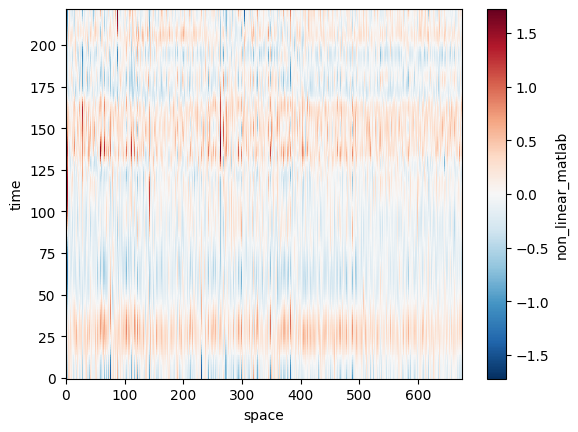

In [9]:
non_linear["non_linear_matlab"].plot(x="space", y="time")

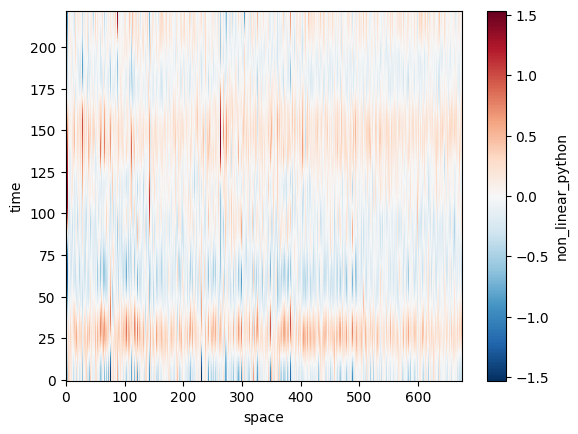

In [10]:
non_linear["non_linear_python"].plot(x="space", y="time")

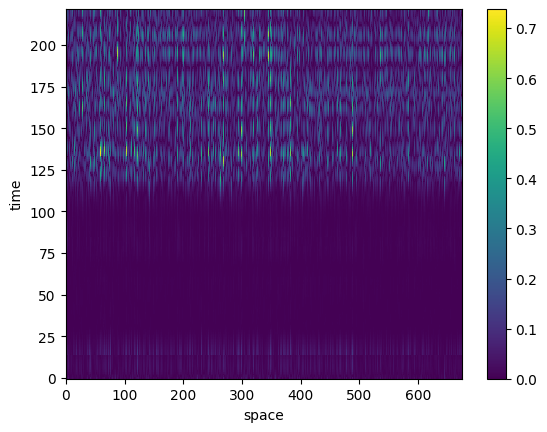

In [11]:
# absolute difference bewteen matlab and python
ae = abs(non_linear["non_linear_python"] - non_linear["non_linear_matlab"])
ae.plot(x="space", y="time")